# Was ist @property grundsätzlich?
@property ist kein Keyword, sondern:

👉 ein eingebauter Python-Decorator, der eine Methode in ein Attribut verwandelt

@.setter ist keine Spracheigenschaft, sondern:

➡️ eine Methode des property-Objekts

align = property(align) # property as decorator, return align
align = align.setter(align_setter)  #align.setter as decorator,  return align


In [2]:
class A:
    @property
    def x(self):
        return 42
a=A()
a.x  # call x(self)

42

In [7]:
class A:
    @property
    def x(self):
        return self._x

    @x.setter
    def x(self, val):
        self._x = val

a=A()     # create class instance
a.x= 10   # assign a value for _x
a.x       # use x als attribut

10

In [8]:
property(fget=None, fset=None, fdel=None)


# Intern:
- Ausdruck	Was passiert
- ann.align	ruft def align(self)
- ann.align = x	ruft def align(self, val)
- self["align"]	Zugriff auf das dict

In [9]:
# dict as baseclass, slef is a instance, a dict and a object-instance
class Annotation(dict):

    @property
    def align(self):
        return self["align"]

    @align.setter
    def align(self, val):
        self["align"] = val


ann = Annotation()

ann.align = "center"   # setter: call align(self, val), "align" as key, self["align"] = val, self=dict
print(ann.align)      # getter: call align(self)


center


In [13]:
import json

# Ein JSON-String (beachte die doppelten Anführungszeichen innen)
json_string = '{"name": "Sarah", "aktiv": true, "alter": 28}'

# 1. JSON-String in ein Python-Dictionary umwandeln
daten = json.loads(json_string)
print(daten["name"])  # Ausgabe: Sarah
print("----")
# 2. Ein Python-Dictionary zurück in einen JSON-String umwandeln
neuer_string = json.dumps(daten, indent=4)
print(neuer_string)
print(type(neuer_string))


Sarah
----
{
    "name": "Sarah",
    "aktiv": true,
    "alter": 28
}
<class 'str'>


In [4]:
class User:
    pass
print("###########")
print(User.__dict__)   # {}
u=User()
print("###########")
print(u.__dict__)   # {}  still empty
u.x=1
u.y=2
u.name="Chen"
u.age=20
print(u.__dict__)   # {}: 4 instanceattributtes added


###########
{'__module__': '__main__', '__dict__': <attribute '__dict__' of 'User' objects>, '__weakref__': <attribute '__weakref__' of 'User' objects>, '__doc__': None}
###########
{}
{'x': 1, 'y': 2, 'name': 'Chen', 'age': 20}


# Warum taucht age NICHT im __dict__ auf? aber _age schon
age ist:

Klassenattribut

ein Descriptor

liegt in User.__dict__

## Diffrence bewtween User.__dict__ and u.__dict__
User: Class

u: Instance

### Python macht bei u.age

Suche in User.__dict__

findet property

ruft property.__get__(u, User)

Getter liefert self._age

_age wird aus u.__dict__ gelesen


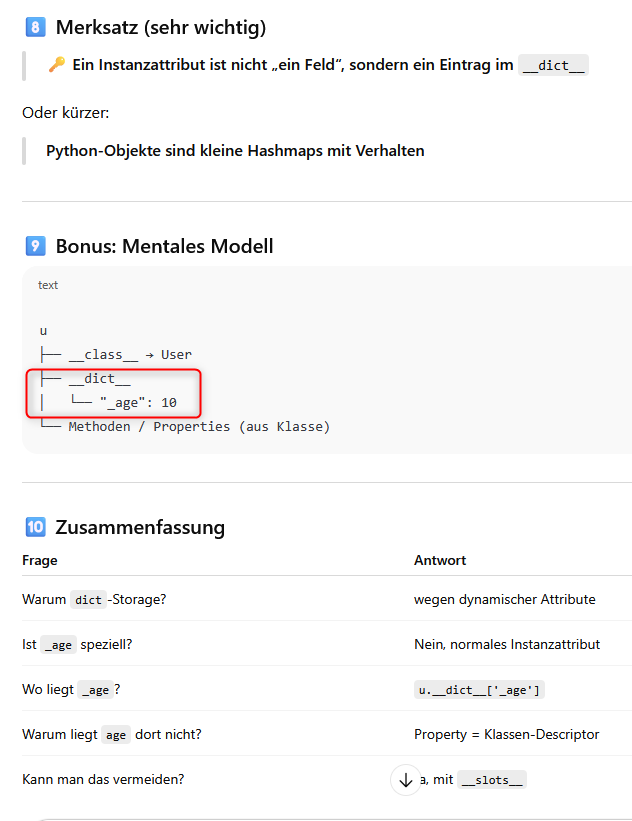

In [3]:
class User:
    @property
    def age(self): 
        return self._age 
u=User()
#age = property(age)
print(u.__dict__)
print()
print(User.__dict__)
print()
print(User.__dict__['age'])


{}

{'__module__': '__main__', 'age': <property object at 0x0000021D62FD4AE0>, '__dict__': <attribute '__dict__' of 'User' objects>, '__weakref__': <attribute '__weakref__' of 'User' objects>, '__doc__': None}



# 1️⃣ PyObject – die Mutter aller Objekte
https://chatgpt.com/c/69556e5b-fa54-832d-a323-85617403a874

# Kurzantwort: Ja – alle sind Attribute.
Aber: sie sind unterschiedliche Arten von Attributen.

Achtung: @property is auch ein Attribute!!!


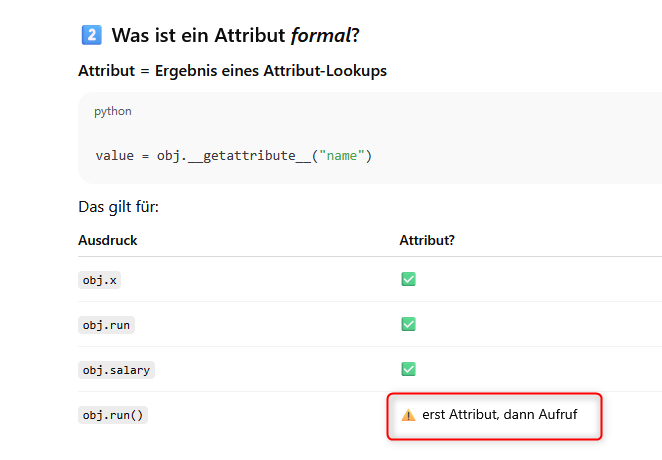


In [14]:
class Car:
    def __init__(self, name, type):
      self.name=name
      self.type=type
        
    def myfunc(self):
       print(self.name)
        
mycar= Car("Ford","Master")
print(mycar.name)
mycar.myfunc()

Ford
Ford


## myfunc ist ein Attribut

## der Wert dieses Attributs ist ein bound method object

## callable → deshalb () möglich

In [23]:
# alle sind Attribute, aber verschiedenen Arte
value = mycar.__getattribute__("name")
mytype = mycar.__getattribute__("type")
func = mycar.__getattribute__("myfunc") # erst Attribute "myfunc",dann Aufruf "myfunc()"
print(type(value))
print(value)
print(mytype)
print(func)
func()
print(callable(mycar.myfunc) ) # True

mycar.myfunc  # Attributtzugriff mycar.myfunc  = mycar.__getattribute__("myfunc")


<class 'str'>
Ford
Master
<bound method Car.myfunc of <__main__.Car object at 0x0000019BD4D0E4E0>>
Ford
True


<bound method Car.myfunc of <__main__.Car object at 0x0000019BD4D0E4E0>>

In [26]:
# simple function: callable ?: true
def testfunc( ):
     print("Hallo")

print(callable(testfunc))  # True

True


# Methode: Attribut, das callable ist
Also:

run ist ein Attribut

der Wert dieses Attributs ist ein bound method object

callable → deshalb () möglich

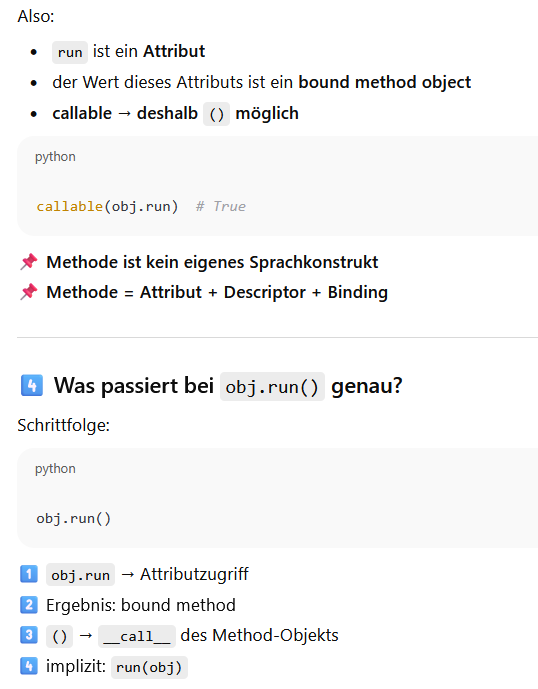

In [28]:
class A:
    def run(self):
        print("running")
obj = A()
obj.run


<bound method A.run of <__main__.A object at 0x0000019BD6D19100>>

# 5️⃣ Property: auch ein Attribut (sehr wichtig!)
- 👉 Attributzugriff
- 👉 Ergebnis ist kein callable
- 👉 Ergebnis ist ein berechneter Wert

## 📌 salary ist:

ein Attribut

gesteuert durch einen Descriptor

kein gespeicherter Wert

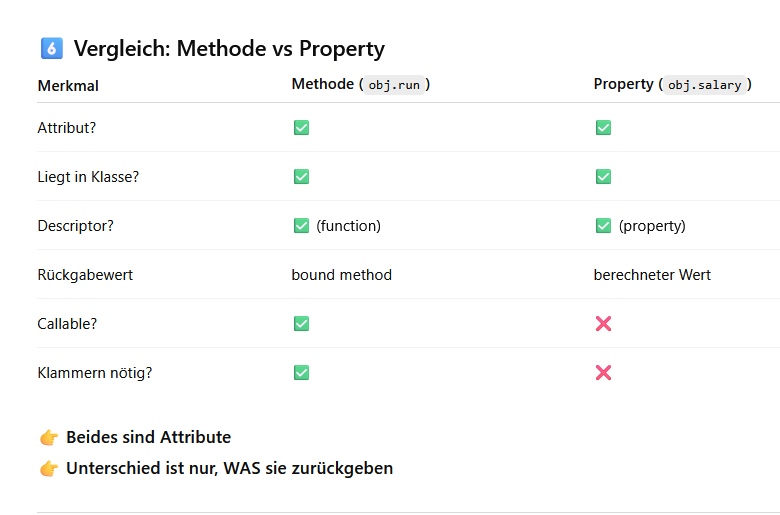

https://chatgpt.com/c/69556e5b-fa54-832d-a323-85617403a874


In [31]:
class Employee:
    @property
    def salary(self):
        return 5000
e = Employee()
print(e.salary)
print(callable(e.salary) ) # False


5000
False
